# Identifying detections with `spacerocks.checker`

Given detections (RA/Dec, time, observer, uncertainty), `spacerocks.checker` finds the known objects each one could be, in the manner of the MPC's MPChecker. For every orbit in a catalog it asks whether the orbit's predicted position, with its uncertainty, is consistent with the detection, with its uncertainty.

The catalog can be:
- the MPC's catalog of every minor planet (**MPCORB**, ~1.4 million orbits), downloaded once to `~/.spacerocks/mpc`. It has no covariances, so each orbit's uncertainty comes from the MPC's uncertainty parameter U;
- orbits you fit with `spacerocks.orbfit`, with their full covariance;
- the MPC's own orbits with covariance (`mpc_orb` records from the MPC's orbit API).

The detections here are real MPC astrometry of (3666) Holman, (433) Eros and (101955) Bennu, from the cache that `orbit_fitting.ipynb` fills (`mpc_cache/`).

The check has two stages. First, a coarse search moves the whole catalog by two-body motion from a nearby reference state. Then each candidate gets a full N-body prediction (ASSIST's force model, with light time), and its uncertainty is mapped through the variational equations. A detection and an orbit are **consistent** when the Mahalanobis distance of their offset is at most `nsigma` (3). The distance is computed with both covariances. See `docs/python-docs/checker.md` for details.

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from spacerocks import checker, orbfit
from spacerocks.spice import SpiceKernel
from spacerocks.observing import Observatory

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

kernel = SpiceKernel.defaults()   # planets, 16 massive asteroids, Earth orientation, leap seconds
ARCSEC = np.pi / (180 * 3600)

## The MPC catalog

`Catalog.mpcorb` reads `~/.spacerocks/mpc/mpcorb_extended.json.gz`, downloading it first if it's missing and `download=True`. The first read parses 1.4 million orbits and integrates the ~1% with older epochs to the common epoch, which takes under a minute. The result is cached next to the file (`.srcat`), so every later load takes about a second. `update=True` downloads a fresh catalog.

In [2]:
t0 = time.time()
cat = checker.Catalog.mpcorb(kernel, download=True)
print(cat, f"({time.time() - t0:.1f} s)")
print("U parameter:", pd.Series(cat.u).value_counts(dropna=False).sort_index().to_dict())

Catalog(1439233 orbits, 0 with covariance, snapshot at JD 2460800.5000000163 TDB) (0.5 s)
U parameter: {0.0: 1035947, 1.0: 116879, 2.0: 72534, 3.0: 39900, 4.0: 30967, 5.0: 32000, 6.0: 28423, 7.0: 26353, 8.0: 24794, 9.0: 18318, nan: 13118}


## Detections

These helpers are the same as in `orbit_fitting.ipynb`: `get_obs` returns an object's MPC astrometry (ADES), cached in `mpc_cache/`, and `detections` keeps ground-based optical detections in a time range. The 1σ uncertainty is the reported rms, floored at 0.1″. Where no rms is reported, it is Vereš et al. (2017).

In [3]:
CACHE = Path("mpc_cache")
CACHE.mkdir(exist_ok=True)


def cached(name, fetch):
    path = CACHE / f"{name}.json"
    if not path.exists():
        path.write_text(json.dumps(fetch()))
    return json.loads(path.read_text())


def get_obs(desig):
    def fetch():
        r = requests.get("https://data.minorplanetcenter.net/api/get-obs",
                         json={"desigs": [desig], "output_format": ["ADES_DF"]}, timeout=300)
        r.raise_for_status()
        return r.json()[0]["ADES_DF"]
    df = pd.DataFrame(cached(f"obs_{desig}", fetch))
    df.columns = df.columns.str.lower()
    return df


def get_mpc_orbit(desig):
    def fetch():
        r = requests.get("https://data.minorplanetcenter.net/api/get-orb", json={"desig": desig}, timeout=120)
        r.raise_for_status()
        return r.json()[0]["mpc_orb"]
    orb = cached(f"orb_{desig}", fetch)
    while isinstance(orb, list):
        orb = orb[0]
    return orb


_ground = {}
def is_ground(code):
    if code not in _ground:
        try:
            _ground[code] = Observatory.from_obscode(code).lat is not None
        except Exception:
            _ground[code] = False
    return _ground[code]


def detections(desig, start=None, end=None):
    df = get_obs(desig)
    df = df[(df.obstype == "optical") & df.ra.notna() & df.stn.map(is_ground)].copy()
    t = pd.to_datetime(df.obstime, format="ISO8601", utc=True)
    keep = np.ones(len(df), bool)
    if start:
        keep &= (t >= pd.Timestamp(start, tz="UTC")).to_numpy()
    if end:
        keep &= (t < pd.Timestamp(end, tz="UTC")).to_numpy()
    df, t = df[keep], t[keep]
    jd = 2451545.0 + (t - pd.Timestamp("2000-01-01T12:00:00", tz="UTC")) / pd.Timedelta(days=1)
    veres = orbfit.veres_sigma(df.stn.tolist(), jd.to_numpy(), catalog=df.astcat.fillna("").tolist(),
                               program=df.prog.fillna("").tolist())
    rms = np.hypot(pd.to_numeric(df.rmsra, errors="coerce"), pd.to_numeric(df.rmsdec, errors="coerce")) / np.sqrt(2) * ARCSEC
    return pd.DataFrame({"object": desig, "jd": jd.to_numpy(), "stn": df.stn.to_numpy(),
                         "ra": np.radians(pd.to_numeric(df.ra)).to_numpy(), "dec": np.radians(pd.to_numeric(df.dec)).to_numpy(),
                         "sigma": np.where(np.isfinite(rms) & (rms > 0), np.maximum(rms, 0.1 * ARCSEC), veres)})


def check(catalog, d, **kw):
    # Check a table of detections; returns the result as a DataFrame, with the true object.
    r = pd.DataFrame(checker.check(catalog, d.ra.values, d.dec.values, d.jd.values, d.stn.tolist(), kernel,
                                   sigma_ra=d.sigma.values, sigma_dec=d.sigma.values, **kw))
    r["truth"] = d.object.values[r.detection]
    return r

## Checking detections against MPCORB

These are three weeks of detections around the catalog's epoch (2025 May 5). Every object moves from its own orbit by two-body motion, so nothing has to be integrated first. The table shows the best match for each detection: consistent pairs come first, then pairs in order of decreasing likelihood.

In [4]:
d = pd.concat([detections(x, "2025-04-26", "2025-05-15") for x in ["3666", "433", "101955"]], ignore_index=True)
t0 = time.time()
r = check(cat, d)
print(f"{len(d)} detections checked against {len(cat):,} orbits in {time.time() - t0:.1f} s")
best = r.groupby("detection").head(1)
print(f"best match is the right object for {(best.name == best.truth).sum()} of {len(d)}; "
      f"consistent: {best.consistent.sum()}")
best[["detection", "truth", "name", "distance", "consistent", "separation", "sigma_major", "mag"]].round(3).head(12)

36 detections checked against 1,439,233 orbits in 2.9 s
best match is the right object for 36 of 36; consistent: 36


,detection,truth,name,distance,consistent,separation,sigma_major,mag
0,0,3666,3666,0.147,True,0.086,0.326,18.870
1,1,3666,3666,0.138,True,0.081,0.326,18.870
2,2,3666,3666,0.218,True,0.127,0.326,18.870
3,3,433,433,0.293,True,0.114,0.338,14.537
5,4,433,433,0.211,True,0.082,0.338,14.537
7,5,433,433,0.327,True,0.117,0.338,14.537
9,6,433,433,0.143,True,0.055,0.338,14.537
11,7,433,433,0.473,True,0.182,0.339,14.522
12,8,433,433,0.610,True,0.229,0.339,14.522
13,9,433,433,0.229,True,0.083,0.339,14.522


By default the result also lists objects predicted within `radius` (60″) of a detection that are not consistent with it: near misses, as MPChecker's search radius shows them. Here is everything reported for one Eros detection:

In [5]:
j = d.index[d.object == "433"][0]
r[r.detection == j][["name", "distance", "consistent", "separation", "dra", "ddec", "sigma_major", "log_likelihood"]].round(2)

,name,distance,consistent,separation,dra,ddec,sigma_major,log_likelihood
3,433,0.29,True,0.11,0.07,0.09,0.34,0.07
4,2013 YN67,2.84,True,393.12,-342.10,-193.68,142.13,-13.51


Eros has U = 0: its predicted position is uncertain by a fraction of an arcsecond. A detection 10″ away is still reported (it's inside `radius`) but isn't consistent with it:

In [6]:
moved = d.copy()
moved["dec"] += 10 * ARCSEC
rm = check(cat, moved)
tm = rm[rm.name == rm.truth]
print(f"right object reported for {tm.detection.nunique()} of {len(d)}, consistent for {tm.consistent.sum()}; "
      f"median distance {tm.distance.median():.0f} sigma")

right object reported for 36 of 36, consistent for 0; median distance 27 sigma


## Orbits with a covariance

The U parameter is coarse. With a covariance, the prediction's uncertainty is the orbit's own, mapped to each detection through the variational equations. Here we fit (3666) Holman to its 2015–2023 detections with `orbfit.fit`, put the fit in a catalog, and check the detections of 2024–2026, which the fit hasn't seen.

If the covariance is right, the Mahalanobis distances of the true detections follow a χ distribution with 2 degrees of freedom.

OrbitFit(flag=0 [converged], chi2=2627.540649, ndof=5066, niter=1, epoch=2460028.98640980 TDB)
814 later detections: 812 consistent, median sigma_major 0.30"


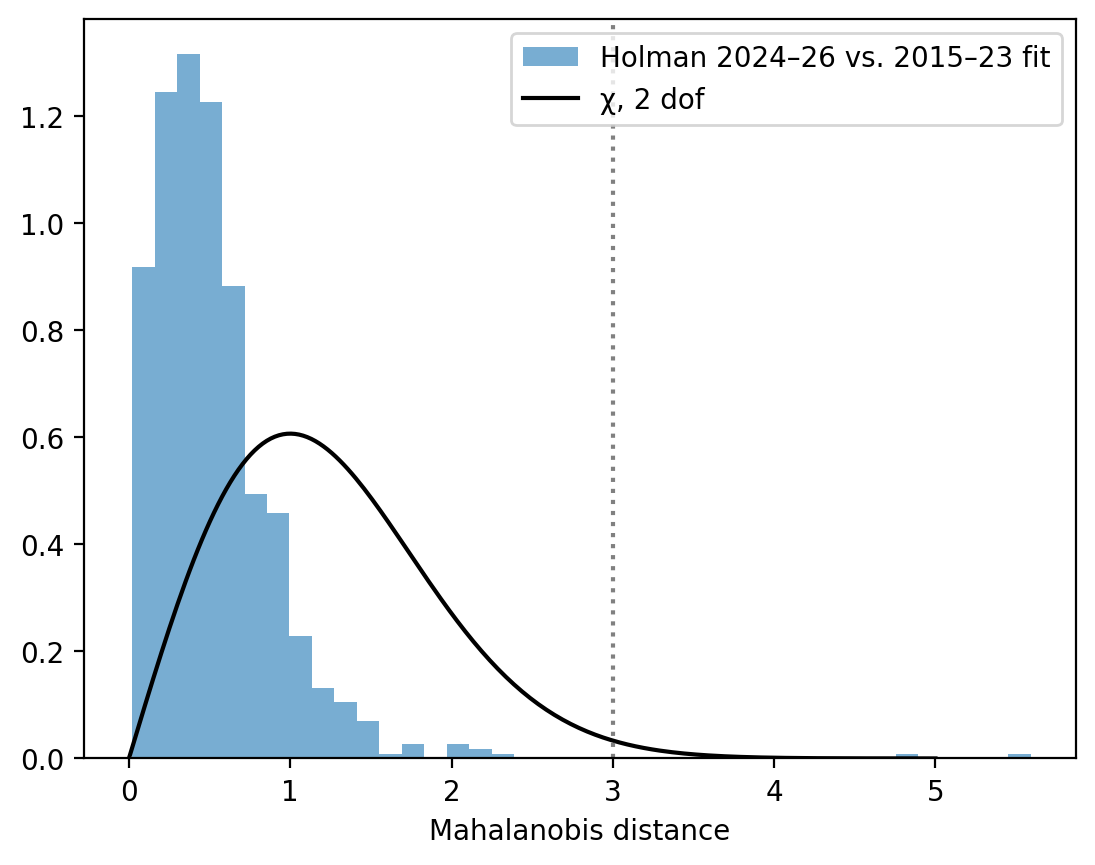

In [7]:
h = detections("3666", "2015-01-01")
train = h[h.jd < 2460310.5]
fit = orbfit.fit(train.ra.values, train.dec.values, train.jd.values, train.stn.tolist(), kernel,
                 sigma_ra=train.sigma.values, sigma_dec=train.sigma.values, robust=True, name="3666")
print(fit)

mine = checker.Catalog.from_fits({"3666 (fit)": fit})
test = h[h.jd >= 2460310.5].reset_index(drop=True)
rf = check(mine, test)
print(f"{len(test)} later detections: {rf.consistent.sum()} consistent, "
      f"median sigma_major {rf.sigma_major.median():.2f}\"")

x = np.linspace(0, 5, 200)
plt.hist(rf.distance, bins=40, density=True, alpha=0.6, label="Holman 2024–26 vs. 2015–23 fit")
plt.plot(x, x * np.exp(-x**2 / 2), "k", label="χ, 2 dof")
plt.axvline(3, color="gray", ls=":")
plt.xlabel("Mahalanobis distance"); plt.legend();

The MPC's own orbit, with its covariance, from the MPC's orbit API. You can mix catalogs with `extend`, for example your own fits plus MPCORB.

In [8]:
mpc = checker.Catalog.from_mpc_orb(get_mpc_orbit("3666"), kernel)
print(mpc, mpc.names)
rm = check(mpc, test)
print(f"MPC orbit: {rm.consistent.sum()} of {len(test)} consistent, median distance {rm.distance.median():.2f}")

Catalog(1 orbits, 1 with covariance) ['3666']
MPC orbit: 812 of 814 consistent, median distance 0.44


## Snapshots: checking far from the catalog's epoch

Two-body motion is used for at most `max_age` days (30 by default) from a reference state. For detections further than that from the catalog's epoch, the whole catalog is first integrated (N-body) to the middle of each cluster of detection epochs. That is slow, and it's repeated on every call. A **snapshot** does the integration once. `Catalog.snapshot` integrates every orbit to one epoch, and `save`/`load` keep the result (about 250 MB).

Here: September 2026, 16 months after the catalog's epoch. On 2 cores the snapshot takes about 3 minutes, and on 10 cores well under a minute.

In [9]:
late = pd.concat([detections(x, "2026-09-01", "2026-09-30") for x in ["3666", "433"]], ignore_index=True)

t0 = time.time()
cat.snapshot(float(np.median(late.jd)), kernel, timescale="utc")
print(f"snapshot: {time.time() - t0:.0f} s")
cat.save("mpcorb_2026sep.srcat")          # later: checker.Catalog.load("mpcorb_2026sep.srcat")

t0 = time.time()
rl = check(cat, late)
best = rl.groupby("detection").head(1)
print(f"{len(late)} detections in {time.time() - t0:.1f} s; best match right and consistent for "
      f"{((best.name == best.truth) & best.consistent).sum()}")

snapshot: 197 s


67 detections in 3.4 s; best match right and consistent for 67
